Dataset Found:
/kaggle/input/datasets/merajsharif/smart-city/smart_city_citizen_activity.csv

Dataset Shape:
(1000, 15)

RQ2 Table (%)
Mode_of_Transport  Bicycle    Car     EV  Public Transport  Walking
Age_Group                                                          
18-29                29.73  15.32  13.96             16.67    24.32
30-44                29.12  19.30  20.00             14.04    17.54
45-59                34.45  17.73  15.38             13.04    19.40
60+                  40.21  12.89  14.43             18.04    14.43


<Figure size 1200x700 with 0 Axes>

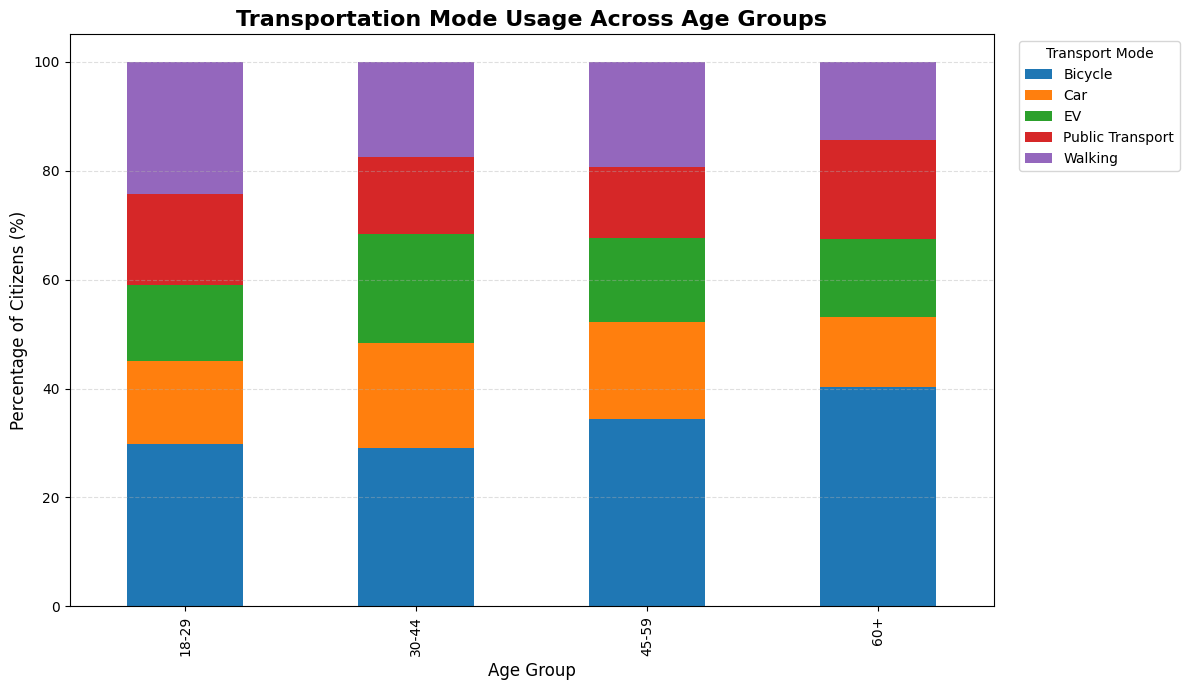


Files Created:
RQ2_Transportation_Usage.csv
RQ2_Transportation_Mode.pdf
RQ2_Summary.csv

ZIP Created:
/kaggle/working/RQ2_Output.zip


In [1]:
# =====================================================
# RQ2
# Whose behaviours are captured and prioritised
# by Smart City AI systems?
#
# Analysis:
# Transportation Mode Usage by Age Group
# =====================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from pathlib import Path

# =====================================================
# FIND DATASET
# =====================================================

citizen_file = None

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:

        if filename == "smart_city_citizen_activity.csv":

            citizen_file = os.path.join(
                dirname,
                filename
            )

print("Dataset Found:")
print(citizen_file)

# =====================================================
# LOAD DATA
# =====================================================

citizen = pd.read_csv(citizen_file)

print("\nDataset Shape:")
print(citizen.shape)

# =====================================================
# CREATE OUTPUT FOLDER
# =====================================================

output_dir = Path("outputs")
output_dir.mkdir(exist_ok=True)

# =====================================================
# CREATE AGE GROUPS
# =====================================================

bins = [18,30,45,60,100]

labels = [
    "18-29",
    "30-44",
    "45-59",
    "60+"
]

citizen["Age_Group"] = pd.cut(
    citizen["Age"],
    bins=bins,
    labels=labels,
    right=False
)

# =====================================================
# STANDARDIZE TRANSPORT LABELS
# =====================================================

citizen["Mode_of_Transport"] = (
    citizen["Mode_of_Transport"]
    .replace({
        "Bike":"Bicycle"
    })
)

# =====================================================
# TABLE
# =====================================================

rq2_table = pd.crosstab(
    citizen["Age_Group"],
    citizen["Mode_of_Transport"]
)

rq2_percentage = (
    rq2_table.div(
        rq2_table.sum(axis=1),
        axis=0
    ) * 100
).round(2)

print("\nRQ2 Table (%)")
print(rq2_percentage)

# Save Table

rq2_percentage.to_csv(
    output_dir /
    "RQ2_Transportation_Usage.csv"
)

# =====================================================
# PUBLICATION READY FIGURE
# =====================================================

plt.figure(figsize=(12,7))

ax = rq2_percentage.plot(
    kind="bar",
    stacked=True,
    figsize=(12,7)
)

plt.title(
    "Transportation Mode Usage Across Age Groups",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Age Group",
    fontsize=12
)

plt.ylabel(
    "Percentage of Citizens (%)",
    fontsize=12
)

plt.legend(
    title="Transport Mode",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.savefig(
    output_dir /
    "RQ2_Transportation_Mode.pdf",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

# =====================================================
# SUMMARY TABLE
# =====================================================

top_transport = (
    citizen["Mode_of_Transport"]
    .value_counts()
    .idxmax()
)

summary = pd.DataFrame({
    "Most_Common_Transport":[
        top_transport
    ]
})

summary.to_csv(
    output_dir /
    "RQ2_Summary.csv",
    index=False
)

# =====================================================
# CREATE DOWNLOADABLE ZIP
# =====================================================

import shutil

shutil.make_archive(
    "/kaggle/working/RQ2_Output",
    "zip",
    "outputs"
)

print("\nFiles Created:")

for f in os.listdir("outputs"):
    print(f)

print("\nZIP Created:")
print("/kaggle/working/RQ2_Output.zip")